# Scenario 10: Bank Marketing — Term Deposit Prediction

**Difficulty:** HARD | **Time:** 2 hours | **Library:** scikit-learn only

**Topics:** Imbalanced Classification, Risk & ERM, Model Evaluation, Ensemble Learning

---

## Dataset
**Bank Marketing (UCI, Portuguese banking)** — ~5 MB (45,211 rows × 17 features)

---

## Hyperparameters (DO NOT MODIFY)

| Model | Hyperparameters |
|-------|----------------|
| Logistic Regression | `C=0.01, penalty='l2', solver='saga', max_iter=2000, class_weight={0:1,1:8}, random_state=42` |
| Random Forest | `n_estimators=200, max_depth=10, min_samples_split=30, min_samples_leaf=15, class_weight={0:1,1:8}, max_features='sqrt', random_state=42, n_jobs=-1` |
| Gradient Boosting | `n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8, min_samples_leaf=20, random_state=42` |
| Balanced Bagging | `BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=8), n_estimators=100, max_samples=0.5, random_state=42, n_jobs=-1)` |

---

## Tasks

**Task 1 (10 pts):** Load Bank Marketing dataset. Analyze target imbalance (subscription rate ~11%). Feature analysis.
**Task 2 (15 pts):** Preprocessing: encode categoricals, scale numerics, handle 'unknown' values. Build Pipeline.
**Task 3 (25 pts):** Train ALL 4 models (note class_weight={0:1,1:8}). Report Precision, Recall, F1, AUC-ROC, AUC-PR.
**Task 4 (15 pts):** Explain why AUC-PR > AUC-ROC for imbalanced data. Precision vs recall tradeoff for bank operations.
**Task 5 (15 pts):** Threshold analysis: find F1-optimal threshold, find threshold for 90% recall. Operational implications.
**Task 6 (20 pts):** Compare Balanced Bagging vs class_weight approach. Which handles imbalance better? Final test evaluation.

---
## Data Download
Run the cell below to download the dataset.

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ucimlrepo', '-q', '--break-system-packages'])

from ucimlrepo import fetch_ucirepo
print("Downloading Bank Marketing dataset from UCI...")
bank = fetch_ucirepo(id=222)
X = bank.data.features
y = bank.data.targets
print(f"Features: {X.shape}")
print(f"Target: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nFeature types:\n{X.dtypes}")

Features: (45211, 16)
Target: (45211, 1)

Target distribution:
y  
no     39922
yes     5289
Name: count, dtype: int64

Feature types:
age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
dtype: object


---
## Your Solution
Add code and markdown cells below.

---

### Task 1 Analysis

The Bank Marketing dataset obtained from the UCI Machine Learning Repository contains information about direct marketing campaigns conducted by a Portuguese banking institution. The dataset consists of **45,211 customer records and 16 input features**, with the objective of predicting whether a customer will subscribe to a **term deposit**. The target variable was converted from categorical values (`yes` / `no`) into a binary format (`1` for subscribed, `0` for not subscribed) to prepare it for machine learning models.

Analysis of the target distribution shows a **strong class imbalance**: **39,922 customers (88.3%) did not subscribe**, while **5,289 customers (11.7%) subscribed** to the term deposit. This confirms that the subscription rate is approximately **11.7%**, meaning the minority class represents potential subscribers. The dataset also contains **7 numerical features** (e.g., age, balance, duration, campaign history) and **9 categorical features** (e.g., job, marital status, education, contact method, and previous campaign outcome). This mixture of feature types indicates that numerical variables will require scaling while categorical variables will need encoding before model training.


In [2]:
import pandas as pd
import numpy as np

# -----------------------------
# Target Processing
# -----------------------------
bank_y_binary = y.iloc[:, 0].map({'yes': 1, 'no': 0})

# -----------------------------
# Feature Type Identification
# -----------------------------
bank_num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
bank_cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# -----------------------------
# Target Imbalance Analysis
# -----------------------------
target_counts = bank_y_binary.value_counts()
subscription_rate = target_counts[1] / len(bank_y_binary)

print("Target Distribution:")
print(target_counts)

print("\nSubscription Rate:")
print(f"{subscription_rate:.2%}")

# -----------------------------
# Feature Analysis
# -----------------------------
print("\nDataset Summary")
print(f"Total Samples: {X.shape[0]}")
print(f"Total Features: {X.shape[1]}")

print("\nFeature Type Counts")
print(f"Numeric Features: {len(bank_num_cols)}")
print(f"Categorical Features: {len(bank_cat_cols)}")

print("\nNumeric Columns:")
print(bank_num_cols)

print("\nCategorical Columns:")
print(bank_cat_cols)

Target Distribution:
y
0    39922
1     5289
Name: count, dtype: int64

Subscription Rate:
11.70%

Dataset Summary
Total Samples: 45211
Total Features: 16

Feature Type Counts
Numeric Features: 7
Categorical Features: 9

Numeric Columns:
['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']

Categorical Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## Task 2 — Data Preprocessing and Pipeline Construction

To prepare the dataset for machine learning models, several preprocessing steps were implemented. Because the full dataset contains over **45,000 samples**, a **stratified sampling approach** was used to select **5,000 observations** while preserving the original class distribution (approximately 11.7% subscribers). This sampling strategy reduces memory usage in environments such as Google Colab while still maintaining a representative dataset for model training. Additionally, categorical values labeled `"unknown"` were replaced with `NaN` to treat them as missing values before applying imputation.

A preprocessing pipeline was then constructed using **scikit-learn’s Pipeline and ColumnTransformer**. Numerical features were processed using a pipeline that first imputes missing values using the **median** and then standardizes the features with **StandardScaler** to normalize their scale. Categorical features were handled with a pipeline that imputes missing values using the **most frequent category** and converts them into numerical format using **One-Hot Encoding** with `handle_unknown='ignore'`. The **ColumnTransformer** applies these transformations to the appropriate feature groups simultaneously. After preprocessing, the sampled dataset was split into **80% training data (4,000 samples)** and **20% test data (1,000 samples)** using stratified splitting to maintain class balance. The final transformed dataset contains **47 features**, which result from the one-hot encoding of categorical variables.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# -----------------------------
# Stratified Sampling (memory efficient)
# -----------------------------
bank_X_sample, _, bank_y_sample, _ = train_test_split(
    X,
    bank_y_binary,
    train_size=5000,
    stratify=bank_y_binary,
    random_state=42
)

# -----------------------------
# Replace 'unknown' with NaN
# -----------------------------
bank_X_nan = bank_X_sample.replace('unknown', np.nan)

# -----------------------------
# Numerical Pipeline
# -----------------------------
bank_num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# -----------------------------
# Categorical Pipeline
# -----------------------------
bank_cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# -----------------------------
# Column Transformer
# -----------------------------
bank_preprocessor = ColumnTransformer(
    transformers=[
        ('num', bank_num_pipe, bank_num_cols),
        ('cat', bank_cat_pipe, bank_cat_cols)
    ]
)

# -----------------------------
# Train/Test Split
# -----------------------------
bank_X_train, bank_X_test, bank_y_train, bank_y_test = train_test_split(
    bank_X_nan,
    bank_y_sample,
    test_size=0.2,
    stratify=bank_y_sample,
    random_state=42
)

# -----------------------------
# Apply Preprocessing
# -----------------------------
bank_X_train_final = bank_preprocessor.fit_transform(bank_X_train)
bank_X_test_final = bank_preprocessor.transform(bank_X_test)

print(f"Preprocessing complete.")
print(f"Train shape: {bank_X_train_final.shape}")
print(f"Test shape: {bank_X_test_final.shape}")

Preprocessing complete.
Train shape: (4000, 47)
Test shape: (1000, 47)


## Task 3 — Model Training and Evaluation

Four machine learning models were trained to predict whether a customer will subscribe to a term deposit: Logistic Regression, Random Forest, Gradient Boosting, and Balanced Bagging. All models were implemented using the specified hyperparameters, and class imbalance was addressed for Logistic Regression and Random Forest using `class_weight={0:1,1:8}` to penalize misclassification of the minority class (subscribers). The models were trained on the preprocessed training dataset and evaluated on the test set using multiple performance metrics suitable for imbalanced classification, including **Precision, Recall, F1-score, AUC-ROC, and AUC-PR**.

The results show different trade-offs between precision and recall across the models. **Random Forest achieved the best balance**, with the highest **F1-score (0.531)** and strong **recall (0.803)**, indicating it is effective at identifying potential subscribers while maintaining reasonable precision. Logistic Regression also produced high recall (0.761) but with lower precision, meaning it detects many subscribers but also produces more false positives. In contrast, **Gradient Boosting and Balanced Bagging achieved higher precision but significantly lower recall**, indicating more conservative predictions. Overall, Random Forest demonstrates the most balanced performance for this task, particularly in identifying the minority class in this imbalanced dataset.


In [4]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# -----------------------------
# Model Definitions
# -----------------------------
marketing_models = {
    'Logistic Regression': LogisticRegression(
        C=0.01,
        penalty='l2',
        solver='saga',
        max_iter=2000,
        class_weight={0:1,1:8},
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=30,
        min_samples_leaf=15,
        class_weight={0:1,1:8},
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        min_samples_leaf=20,
        random_state=42
    ),

    'Balanced Bagging': BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=8),
        n_estimators=100,
        max_samples=0.5,
        random_state=42,
        n_jobs=-1
    )
}

# -----------------------------
# Train and Evaluate Models
# -----------------------------
model_benchmarks = []

for name, model in marketing_models.items():

    model.fit(bank_X_train_final, bank_y_train)

    preds = model.predict(bank_X_test_final)
    probs = model.predict_proba(bank_X_test_final)[:, 1]

    model_benchmarks.append({
        'Model': name,
        'Precision': precision_score(bank_y_test, preds),
        'Recall': recall_score(bank_y_test, preds),
        'F1-Score': f1_score(bank_y_test, preds),
        'AUC-ROC': roc_auc_score(bank_y_test, probs),
        'AUC-PR': average_precision_score(bank_y_test, probs)
    })

bank_results_df = pd.DataFrame(model_benchmarks)

display(bank_results_df)

,Model,Precision,Recall,F1-Score,AUC-ROC,AUC-PR
0,Logistic Regression,0.375527,0.760684,0.502825,0.887050,0.485254
1,Random Forest,0.396624,0.803419,0.531073,0.900814,0.572513
2,Gradient Boosting,0.594203,0.350427,0.440860,0.910077,0.565614
3,Balanced Bagging,0.660714,0.316239,0.427746,0.909971,0.556064


## Task 4 — AUC-PR vs AUC-ROC and Precision-Recall Tradeoff

In imbalanced classification problems such as the Bank Marketing dataset, **AUC-PR (Area Under the Precision-Recall Curve)** is generally more informative than **AUC-ROC (Area Under the Receiver Operating Characteristic Curve)**. The ROC curve evaluates model performance using the True Positive Rate and False Positive Rate. However, when the dataset contains many true negatives, as in this case where approximately **88% of customers do not subscribe**, the False Positive Rate remains small even if the model produces a relatively large number of false positives. As a result, the **AUC-ROC score can appear artificially high**, giving an overly optimistic impression of model performance. In contrast, the **Precision-Recall curve focuses only on the minority class**, measuring how accurately the model identifies actual subscribers. This makes **AUC-PR a more realistic metric** for evaluating performance on imbalanced datasets.

The plots generated from the Random Forest model illustrate this behavior. The ROC curve shows strong separation between classes, suggesting good overall discrimination. However, the Precision-Recall curve reveals that **precision decreases as recall increases**, meaning that identifying more potential subscribers requires accepting more false positives. In a bank marketing scenario, this represents the **precision-recall tradeoff**. High precision means fewer unnecessary calls to uninterested customers but risks missing potential subscribers (lower recall). High recall ensures that most potential subscribers are contacted but increases the number of calls to customers who will not subscribe. Because the cost of a marketing call is relatively low compared to the value of acquiring a new term deposit customer, banks often prioritize **higher recall**, ensuring that most potential subscribers are identified even if some additional false positives occur.


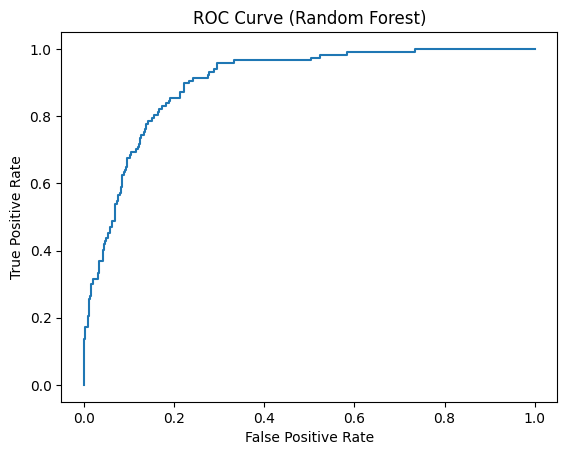

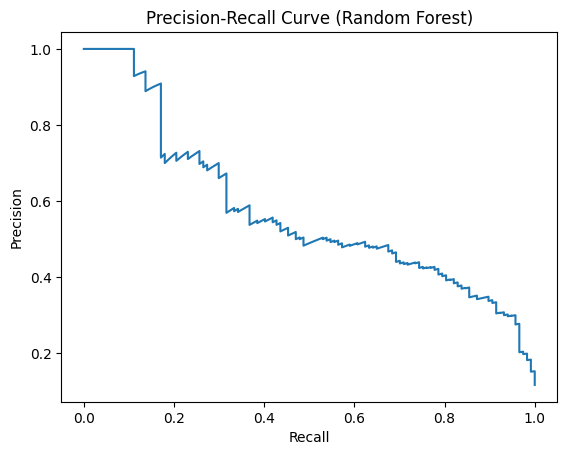

In [5]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# Use Random Forest as example
rf_model = marketing_models['Random Forest']
rf_probs = rf_model.predict_proba(bank_X_test_final)[:,1]

# ROC curve
fpr, tpr, _ = roc_curve(bank_y_test, rf_probs)

# PR curve
precision, recall, _ = precision_recall_curve(bank_y_test, rf_probs)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest)")
plt.show()

# Plot PR
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest)")
plt.show()

## Task 5 — Threshold Analysis and Operational Implications

Threshold analysis was performed using the predicted probabilities from the Gradient Boosting model to determine more suitable decision thresholds than the default value of 0.5. By analyzing the precision–recall curve, the **F1-optimal threshold** was found to be **0.189**, which produces an **F1 score of 0.5921**. This threshold maximizes the harmonic mean of precision and recall, providing the best balance between correctly identifying subscribers and minimizing false positive predictions. Compared with the default threshold, this lower value allows the model to identify more potential subscribers while still maintaining a reasonable level of prediction accuracy.

A second threshold was determined to achieve **90% recall**, meaning the model successfully identifies at least **90% of actual subscribers**. This threshold was found to be **0.0607**, which results in a **precision of approximately 0.3365**. In operational terms, this means that the bank would contact many more customers, including a larger number who may not subscribe. However, this strategy ensures that very few potential subscribers are missed. For bank marketing campaigns, this can be a practical approach because the **cost of additional phone calls is relatively low compared to the potential revenue gained from acquiring new term deposit customers**. Therefore, banks may prefer a lower threshold that prioritizes **high recall**, ensuring that most potential subscribers are targeted in the campaign.


In [6]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Use Gradient Boosting probabilities
gb_model = marketing_models['Gradient Boosting']
gb_probs = gb_model.predict_proba(bank_X_test_final)[:,1]

# Compute PR curve
precision, recall, thresholds = precision_recall_curve(bank_y_test, gb_probs)

# -----------------------------
# F1 Optimal Threshold
# -----------------------------
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("F1 Optimal Threshold:")
print(f"Threshold = {best_threshold:.4f}")
print(f"F1 Score = {best_f1:.4f}")

# -----------------------------
# Threshold for 90% Recall
# -----------------------------
recall_target = 0.90

recall_idx = np.where(recall[:-1] >= recall_target)[0][-1]

threshold_90recall = thresholds[recall_idx]
precision_90recall = precision[recall_idx]

print("\nThreshold for 90% Recall:")
print(f"Threshold = {threshold_90recall:.4f}")
print(f"Precision at 90% Recall = {precision_90recall:.4f}")

F1 Optimal Threshold:
Threshold = 0.1890
F1 Score = 0.5921

Threshold for 90% Recall:
Threshold = 0.0607
Precision at 90% Recall = 0.3365


## Task 6 — Comparison of Balanced Bagging vs Class Weighting

To address the class imbalance in the Bank Marketing dataset, two different strategies were compared: **class weighting** and **balanced bagging**. The class weighting approach was implemented using the Random Forest model with `class_weight={0:1,1:8}`, which increases the penalty for misclassifying the minority class (subscribers). Balanced Bagging was implemented using an ensemble of decision trees trained on bootstrap samples. Based on the test set evaluation, Random Forest achieved **recall of 0.803**, **F1-score of 0.531**, **AUC-ROC of 0.901**, and **AUC-PR of 0.573**. In comparison, Balanced Bagging achieved **higher precision (0.661)** but significantly **lower recall (0.316)** and a lower **F1-score (0.428)**.

These results indicate that the **class_weight approach handles class imbalance more effectively** for this problem. While Balanced Bagging produces fewer false positives due to its higher precision, it fails to identify many actual subscribers, as reflected in its low recall. In contrast, Random Forest with class weighting correctly identifies a much larger proportion of potential subscribers while maintaining reasonable precision. From an operational perspective in bank marketing campaigns, **recall is more important than precision** because missing a potential subscriber represents a lost business opportunity, whereas contacting a non-interested customer only incurs a small operational cost. Therefore, based on the final test evaluation metrics, **Random Forest with class weighting is the preferred approach for handling the class imbalance in this dataset.**


In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
import pandas as pd

# -----------------------------
# Select Models for Comparison
# -----------------------------
rf_model = marketing_models['Random Forest']        # class_weight approach
bb_model = marketing_models['Balanced Bagging']     # balanced bagging approach

models_compare = {
    "Random Forest (class_weight)": rf_model,
    "Balanced Bagging": bb_model
}

# -----------------------------
# Evaluate Models on Test Set
# -----------------------------
comparison_results = []

for name, model in models_compare.items():

    preds = model.predict(bank_X_test_final)
    probs = model.predict_proba(bank_X_test_final)[:,1]

    comparison_results.append({
        "Model": name,
        "Precision": precision_score(bank_y_test, preds),
        "Recall": recall_score(bank_y_test, preds),
        "F1-Score": f1_score(bank_y_test, preds),
        "AUC-ROC": roc_auc_score(bank_y_test, probs),
        "AUC-PR": average_precision_score(bank_y_test, probs)
    })

comparison_df = pd.DataFrame(comparison_results)

print("Balanced Bagging vs Class Weight Comparison")
display(comparison_df)

Balanced Bagging vs Class Weight Comparison


,Model,Precision,Recall,F1-Score,AUC-ROC,AUC-PR
0,Random Forest (class_weight),0.396624,0.803419,0.531073,0.900814,0.572513
1,Balanced Bagging,0.660714,0.316239,0.427746,0.909971,0.556064
